In [ ]:
# data loaded
import pandas as pd
loan  = pd.read_csv('loan_approval_data.csv')

print(f"Dataset Shape: {loan.shape}") # to check structural dimensions(rows,columns)

# inspect for missing values
print("-- DATA OF LOAN APPROVAL --")
loan.info()
loan.head(10)


Dataset Shape: (1000, 20)
-- DATA OF LOAN APPROVAL --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Pr

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
5,6.0,8265.0,4831.0,Salaried,53.0,Single,1.0,602.0,1.0,0.56,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.0,Salaried,58.0,Married,0.0,687.0,0.0,0.48,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,8.0,6426.0,3186.0,Salaried,47.0,Married,2.0,636.0,4.0,NaN,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,NaN,No
8,9.0,16423.0,NaN,Salaried,54.0,Married,1.0,729.0,0.0,0.59,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,10.0,13363.0,2599.0,Contract,35.0,Single,3.0,726.0,1.0,NaN,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


In [ ]:
clean_loan = loan.dropna(subset=["Credit_Score","DTI_Ratio", "Loan_Amount","Loan_Approved"]).copy()
print(f"The original records: {len(loan)}")
print(f"The clean records for analysis: {len(clean_loan)}")
print(f"Total null records removed from system: {len(loan) - len(clean_loan)}")

The original records: 1000
The clean records for analysis: 816
Total null records removed from system: 184


In [ ]:
import sqlite3
conn = sqlite3.connect(':memory:')

# 2. Dump your cleaned Pandas DataFrame into the SQL database as a table named 'loans'
clean_loan.to_sql('loans', conn, index=False, if_exists='replace')

query = """
SELECT
    Loan_Approved,
    COUNT(*) AS Total_Applications,
    ROUND(AVG(Credit_Score), 1) AS Avg_Credit_Score,
    ROUND(MIN(Credit_Score), 1) AS Min_Credit_Score,
    ROUND(AVG(DTI_Ratio), 2) AS Avg_DTI_Ratio,
    ROUND(MAX(DTI_Ratio), 2) AS Max_DTI_Ratio
FROM loans
GROUP BY Loan_Approved;
"""

# 4. Use Pandas to run the SQL query against the database and display it beautifully
sql_audit_results = pd.read_sql_query(query, conn)
sql_audit_results

,Loan_Approved,Total_Applications,Avg_Credit_Score,Min_Credit_Score,Avg_DTI_Ratio,Max_DTI_Ratio
0,No,558,652.8,550.0,0.40,0.60
1,Yes,258,725.5,651.0,0.25,0.39


In [ ]:
def loan_checker(row):
  if row['Credit_Score'] < 651:
    return 'Rejected due to low credit score'

  if row['DTI_Ratio'] > 0.39:
    return 'Rejected due to high debt to income'

  return 'Approved'

clean_loan['Engine_Decision'] = clean_loan.apply(loan_checker)
print("--- ENGINE EVALUATION COMPLETE ---")
print(clean_loan[['Applicant_ID', 'Credit_Score', 'DTI_Ratio', 'Loan_Approved', 'Engine_Decision']].head(10))

--- ENGINE EVALUATION COMPLETE ---
    Applicant_ID  Credit_Score  DTI_Ratio Loan_Approved  \
0            1.0         637.0       0.53            No   
1            2.0         621.0       0.30            No   
2            3.0         674.0       0.20           Yes   
3            4.0         579.0       0.31            No   
4            5.0         721.0       0.29           Yes   
5            6.0         602.0       0.56            No   
6            7.0         687.0       0.48            No   
8            9.0         729.0       0.59            No   
10          11.0         688.0       0.13           Yes   
11          12.0         743.0       0.23           Yes   

                        Engine_Decision  
0      Rejected due to low credit score  
1      Rejected due to low credit score  
2                              Approved  
3      Rejected due to low credit score  
4                              Approved  
5      Rejected due to low credit score  
6   Rejected due to h

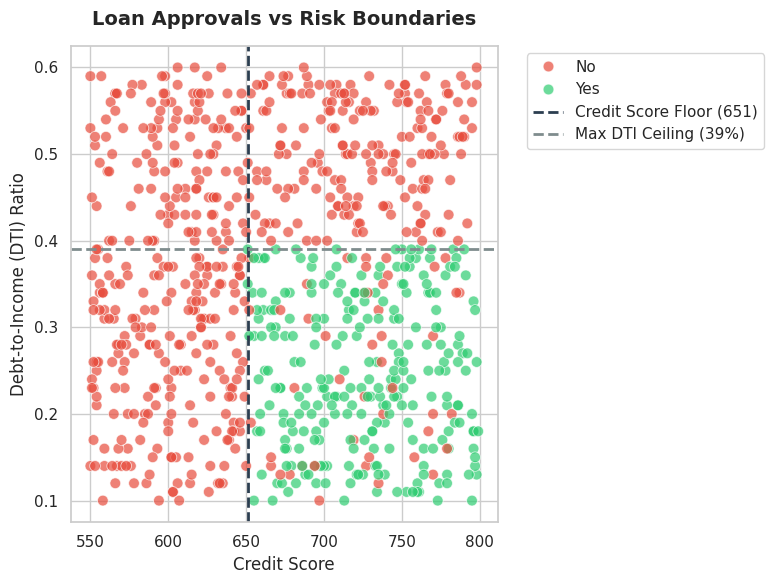

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=clean_loan,
    x='Credit_Score',
    y='DTI_Ratio',
    hue='Loan_Approved',
    palette={'Yes': '#2ecc71', 'No': '#e74c3c'},
    alpha=0.7,
    edgecolor='w',
    s=60
)

plt.axvline(x=651, color='#2c3e50', linestyle='--', linewidth=2, label='Credit Score Floor (651)')
plt.axhline(y=0.39, color='#7f8c8d', linestyle='--', linewidth=2, label='Max DTI Ceiling (39%)')

plt.title('Loan Approvals vs Risk Boundaries', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Debt-to-Income (DTI) Ratio', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


/tmp/ipykernel_7945/1544492960.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7945/1544492960.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


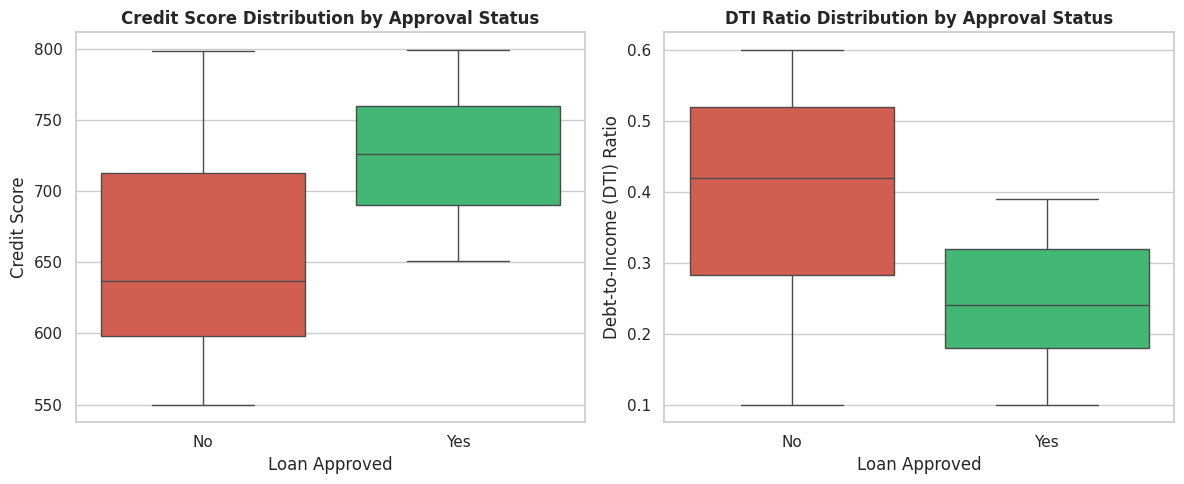

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(
    data=clean_loan,
    x='Loan_Approved',
    y='Credit_Score',
    ax=axes[0],
    palette={'Yes': '#2ecc71', 'No': '#e74c3c'}
)
axes[0].set_title('Credit Score Distribution by Approval Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loan Approved')
axes[0].set_ylabel('Credit Score')

sns.boxplot(
    data=clean_loan,
    x='Loan_Approved',
    y='DTI_Ratio',
    ax=axes[1],
    palette={'Yes': '#2ecc71', 'No': '#e74c3c'}
)
axes[1].set_title('DTI Ratio Distribution by Approval Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loan Approved')
axes[1].set_ylabel('Debt-to-Income (DTI) Ratio')

plt.tight_layout()

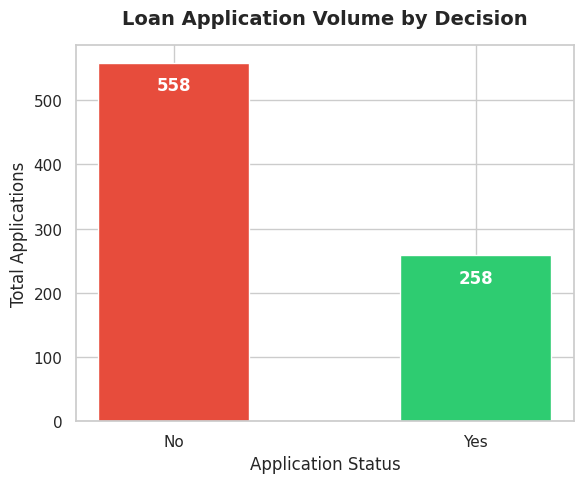

In [ ]:
clean_loan_df = loan.dropna(subset=['Credit_Score', 'DTI_Ratio', 'Loan_Amount', 'Loan_Approved']).copy()
summary = clean_loan_df['Loan_Approved'].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))

bar_colors = ['#e74c3c' if status == 'No' else '#2ecc71' for status in summary.index]

bars = ax.bar(summary.index, summary.values, color=bar_colors, width=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height - 35),
                ha='center', va='center',
                color='white', fontweight='bold', fontsize=12)

ax.set_title('Loan Application Volume by Decision', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Application Status', fontsize=12)
ax.set_ylabel('Total Applications', fontsize=12)

plt.tight_layout()